In [1]:
# =====================================================
# CELL 1 — SETUP + DATA PREPARATION
# =====================================================

import re
import html
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cudnn.enabled = False
torch.backends.cudnn.benchmark = False

# PREPROCESSING
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stop_words_id = set(stop_factory.get_stop_words())

protected_stopwords = {
    'tidak','tidakkah','tidaklah','tak','bukan','bukankah','bukanlah','bukannya','tanpa','belum','belumlah',
    'jangan','janganlah','jangankan','enggak','enggaknya','aku','akulah','saya','sayalah','kami','kamilah',
    'kita','kitalah','kamu','kamulah','anda','andalah','dia','dialah','ia','ialah','mereka','merekalah',
    'apa','apaan','apakah','apatah','bagaimana','bagaimanakah','berapa','berapakah','berapalah','bilakah',
    'kapan','kapankah','kenapa','mengapa','siapa','siapakah','siapapun','mana','bisakah','bolehkah',
    'bolehlah','perlukah','mungkinkah','haruskah','benarkah','sudahkah','tapi','tetapi','namun','melainkan',
    'padahal','walau','walaupun','meski','meskipun','sebaliknya','malah','malahan'
}

final_stopwords = stop_words_id - protected_stopwords


def preprocess_text(text):

    if not isinstance(text,str):
        return []

    text=text.lower()
    text=re.sub(r'@\w+','',text)
    text=re.sub(r'http\S+|www\S+','',text)
    text=re.sub(r'<.*?>','',text)
    text=html.unescape(text)
    text=re.sub(r'[^a-zA-Z#\s]',' ',text)
    text=re.sub(r'\s+',' ',text).strip()

    tokens=text.split()
    tokens=[t for t in tokens if t not in final_stopwords]
    tokens=[stemmer.stem(t) for t in tokens]

    return tokens


# LOAD DATA
dataset_a=pd.read_csv("t5_100.csv")
dataset_b=pd.read_csv("data_20.csv")

X_a=dataset_a["Text"]
y_a=dataset_a["label"]

X_train_text,X_val_text,y_train,y_val=train_test_split(
X_a,y_a,
test_size=0.125,
random_state=42,
stratify=y_a
)

X_test_text=dataset_b["Text"]
y_test=dataset_b["label"]

print("Preprocessing...")

X_train_tokens=[preprocess_text(t) for t in tqdm(X_train_text)]
X_val_tokens=[preprocess_text(t) for t in tqdm(X_val_text)]
X_test_tokens=[preprocess_text(t) for t in tqdm(X_test_text)]


# BUILD VOCAB
word_index={}

for tokens in X_train_tokens:
    for word in tokens:
        if word not in word_index:
            word_index[word]=len(word_index)+1

vocab_size=len(word_index)+1
print("Vocab size:",vocab_size)


# LOAD FASTTEXT
embedding_dim=300
fasttext_path=r"C:\SKRIPSI BRYAN\cc.id.300.vec"

print("Loading FastText...")

embedding_matrix=np.random.normal(scale=0.6,size=(vocab_size,embedding_dim))

found_words=0

with open(fasttext_path,'r',encoding='utf-8',errors='ignore') as f:

    next(f)

    for line in f:

        values=line.rstrip().split(' ')
        word=values[0]

        if word in word_index:

            vector=np.asarray(values[1:],dtype='float32')
            idx=word_index[word]

            embedding_matrix[idx]=vector
            found_words+=1

print("Coverage:",found_words/vocab_size)

embedding_matrix=torch.tensor(embedding_matrix,dtype=torch.float32)


# SEQUENCE
def texts_to_sequences(token_list):
    return [[word_index.get(w,0) for w in tokens] for tokens in token_list]

X_train_seq=texts_to_sequences(X_train_tokens)
X_val_seq=texts_to_sequences(X_val_tokens)
X_test_seq=texts_to_sequences(X_test_tokens)


# PADDING
max_len=50

def pad_sequences(sequences):

    padded=np.zeros((len(sequences),max_len))

    for i,seq in enumerate(sequences):

        seq=seq[:max_len]
        padded[i,:len(seq)]=seq

    return padded

X_train_pad=pad_sequences(X_train_seq)
X_val_pad=pad_sequences(X_val_seq)
X_test_pad=pad_sequences(X_test_seq)


# DATASET CLASS
class TextDataset(Dataset):

    def __init__(self,X,y):

        self.X=torch.tensor(X,dtype=torch.long)
        self.y=torch.tensor(y.values,dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]

Using device: cuda
Preprocessing...


100%|██████████| 3523/3523 [02:42<00:00, 21.63it/s]


Vocab size: 19977
Loading FastText...
Coverage: 0.7550683285778645


In [4]:
# =====================================================
# CELL 2 — HYPERPARAMETER TUNING
# =====================================================

import itertools

subset = 5000

X_tune = X_train_pad[:subset]
y_tune = y_train[:subset]

param_grid = {
"batch_size":[16,32],
"lr":[0.001,0.0005, 0.0001],
"hidden_dim":[32,64],
"dropout":[0.3,0.5]
}

best_recall = 0
best_params = None

for batch_size, lr, hidden_dim, dropout in itertools.product(
param_grid["batch_size"],
param_grid["lr"],
param_grid["hidden_dim"],
param_grid["dropout"]
):

    print("\nTesting:", batch_size, lr, hidden_dim, dropout)

    train_loader = DataLoader(TextDataset(X_tune,y_tune), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TextDataset(X_val_pad,y_val), batch_size=batch_size)

    class BiLSTM(nn.Module):

        def __init__(self):

            super().__init__()

            self.embedding = nn.Embedding.from_pretrained(
                embedding_matrix,
                freeze=True
            )

            self.lstm = nn.LSTM(
                embedding_dim,
                hidden_dim,
                batch_first=True,
                bidirectional=True
            )

            self.dropout = nn.Dropout(dropout)

            self.fc = nn.Linear(hidden_dim*2,1)

        def forward(self,x):

            x = self.embedding(x)

            _,(hidden,_) = self.lstm(x)

            hidden = torch.cat((hidden[0],hidden[1]),dim=1)

            hidden = self.dropout(hidden)

            return self.fc(hidden).squeeze()

    model = BiLSTM().to(device)

    optimizer = torch.optim.Adam(model.parameters(),lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    model.train()

    for epoch in range(10):

        for X_batch,y_batch in train_loader:

            X_batch,y_batch = X_batch.to(device),y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs,y_batch)

            loss.backward()

            optimizer.step()

    # ===== VALIDATION =====

    model.eval()

    preds = []
    true  = []

    with torch.no_grad():

        for X_batch,y_batch in val_loader:

            X_batch = X_batch.to(device)

            probs = torch.sigmoid(model(X_batch))

            preds.extend((probs>=0.5).cpu().numpy())

            true.extend(y_batch.numpy())

    recall = recall_score(true,preds)

    print("Recall:",recall)

    if recall > best_recall:

        best_recall = recall

        best_params = {
        "batch_size":batch_size,
        "lr":lr,
        "hidden_dim":hidden_dim,
        "dropout":dropout
        }

print("\nBest Hyperparameters:",best_params)
print("Best Recall:",best_recall)

with open("hyperparameters_bilstm.json","w") as f:
    json.dump(best_params,f)


Testing: 16 0.001 32 0.3
Recall: 0.6815476190476191

Testing: 16 0.001 32 0.5
Recall: 0.6785714285714286

Testing: 16 0.001 64 0.3
Recall: 0.5982142857142857

Testing: 16 0.001 64 0.5
Recall: 0.6636904761904762

Testing: 16 0.0005 32 0.3
Recall: 0.5714285714285714

Testing: 16 0.0005 32 0.5
Recall: 0.5684523809523809

Testing: 16 0.0005 64 0.3
Recall: 0.6220238095238095

Testing: 16 0.0005 64 0.5
Recall: 0.6130952380952381

Testing: 16 0.0001 32 0.3
Recall: 0.44345238095238093

Testing: 16 0.0001 32 0.5
Recall: 0.40476190476190477

Testing: 16 0.0001 64 0.3
Recall: 0.4523809523809524

Testing: 16 0.0001 64 0.5
Recall: 0.4375

Testing: 32 0.001 32 0.3
Recall: 0.7053571428571429

Testing: 32 0.001 32 0.5
Recall: 0.7410714285714286

Testing: 32 0.001 64 0.3
Recall: 0.5982142857142857

Testing: 32 0.001 64 0.5
Recall: 0.6458333333333334

Testing: 32 0.0005 32 0.3
Recall: 0.5446428571428571

Testing: 32 0.0005 32 0.5
Recall: 0.5386904761904762

Testing: 32 0.0005 64 0.3
Recall: 0.485119047

**recall**

Using hyperparameters: {'batch_size': 32, 'lr': 0.001, 'hidden_dim': 32, 'dropout': 0.5}
🚀 Training dengan Early Stopping (monitor = Val Recall)


Epoch 1/20
Train Loss: 0.4347
Validation Recall: 0.8281
✅ Model terbaik diperbarui


Epoch 2/20
Train Loss: 0.3208
Validation Recall: 0.8842
✅ Model terbaik diperbarui


Epoch 3/20
Train Loss: 0.2901
Validation Recall: 0.8667
⚠️ Tidak ada peningkatan (1/5)


Epoch 4/20
Train Loss: 0.2632
Validation Recall: 0.8393
⚠️ Tidak ada peningkatan (2/5)


...

Epoch 7/20
Train Loss: 0.2148
Validation Recall: 0.8751
⚠️ Tidak ada peningkatan (2/5)


Epoch 8/20
Train Loss: 0.2040
Validation Recall: 0.8625
⚠️ Tidak ada peningkatan (3/5)


Epoch 9/20
Train Loss: 0.1917
Validation Recall: 0.8793
⚠️ Tidak ada peningkatan (4/5)


Epoch 10/20
Train Loss: 0.1843
Validation Recall: 0.8505
⚠️ Tidak ada peningkatan (5/5)
🛑 Early stopping triggered
✅ Training selesai



=== FINAL TEST EVALUATION ===
Accuracy : 0.8441669032074937
Precision: 0.5672131147540984
Recall   : 0.7723214285714286
F1-score : 0.6540642722117203
AUC      : 0.8895672571027708

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9413    0.8611    0.8994      2851
           1     0.5672    0.7723    0.6541       672

    accuracy                         0.8442      3523
   macro avg     0.7543    0.8167    0.7767      3523
weighted avg     0.8700    0.8442    0.8526      3523

=== CONFUSION MATRIX ===
[[2455  396]
 [ 153  519]]


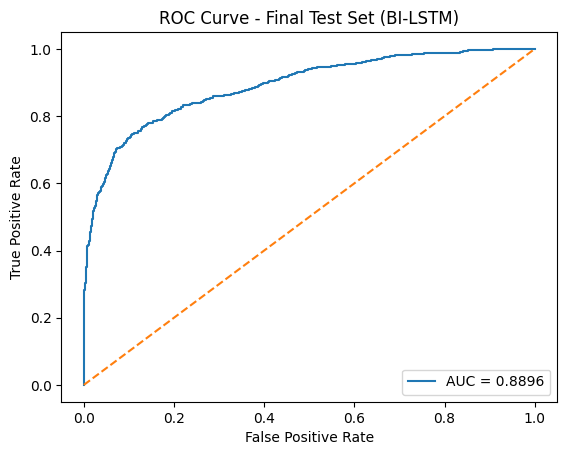

In [2]:
# =====================================================
# CELL 3 — FINAL TRAINING + EVALUATION
# =====================================================

import copy
import json

with open("hyperparameters_bilstm.json") as f:
    params=json.load(f)

print("Using hyperparameters:",params)

batch_size=params["batch_size"]
lr=params["lr"]
hidden_dim=params["hidden_dim"]
dropout=params["dropout"]

train_loader=DataLoader(TextDataset(X_train_pad,y_train),batch_size=batch_size,shuffle=True)
val_loader=DataLoader(TextDataset(X_val_pad,y_val),batch_size=batch_size)
test_loader=DataLoader(TextDataset(X_test_pad,y_test),batch_size=batch_size)


class BiLSTM(nn.Module):

    def __init__(self):

        super(BiLSTM,self).__init__()

        self.embedding=nn.Embedding.from_pretrained(
        embedding_matrix,
        freeze=True
        )

        self.lstm=nn.LSTM(
        embedding_dim,
        hidden_dim,
        batch_first=True,
        bidirectional=True
        )

        self.dropout=nn.Dropout(dropout)

        self.fc=nn.Linear(hidden_dim*2,1)

    def forward(self,x):

        x=self.embedding(x)

        _,(hidden,_)=self.lstm(x)

        hidden=torch.cat((hidden[0],hidden[1]),dim=1)

        hidden=self.dropout(hidden)

        out=self.fc(hidden)

        return out.squeeze()


model=BiLSTM().to(device)

criterion=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=lr)


epochs=20
patience=5
best_recall=0
counter=0
best_model_state=None

print("🚀 Training dengan Early Stopping (monitor = Val Recall)")

for epoch in range(epochs):

    model.train()
    total_loss=0

    train_loop=tqdm(train_loader,desc=f"Epoch {epoch+1}/{epochs} - Training",leave=False)

    for X_batch,y_batch in train_loop:

        X_batch,y_batch=X_batch.to(device),y_batch.to(device)

        optimizer.zero_grad()

        outputs=model(X_batch)

        loss=criterion(outputs,y_batch)

        loss.backward()

        optimizer.step()

        total_loss+=loss.item()

        train_loop.set_postfix(loss=loss.item())

    model.eval()

    val_preds=[]
    val_true=[]

    val_loop=tqdm(val_loader,desc=f"Epoch {epoch+1}/{epochs} - Validation",leave=False)

    with torch.no_grad():

        for X_batch,y_batch in val_loop:

            X_batch=X_batch.to(device)

            outputs=model(X_batch)

            probs=torch.sigmoid(outputs)

            preds=(probs>=0.5).cpu().numpy()

            val_preds.extend(preds)

            val_true.extend(y_batch.numpy())

    val_recall=recall_score(val_true,val_preds,pos_label=1)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {total_loss/len(train_loader):.4f}")
    print(f"Validation Recall: {val_recall:.4f}")

    if val_recall>best_recall:

        best_recall=val_recall
        counter=0
        best_model_state=copy.deepcopy(model.state_dict())

        print("✅ Model terbaik diperbarui")

    else:

        counter+=1

        print(f"⚠️ Tidak ada peningkatan ({counter}/{patience})")

        if counter>=patience:

            print("🛑 Early stopping triggered")
            break

print("✅ Training selesai")


# ================= EVALUATION =================

model.load_state_dict(best_model_state)
model.eval()

all_preds=[]
all_probs=[]

test_loop=tqdm(test_loader,desc="Testing",leave=False)

with torch.no_grad():

    for X_batch,_ in test_loop:

        X_batch=X_batch.to(device)

        outputs=model(X_batch)

        probs=torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())

        all_preds.extend((probs>=0.5).cpu().numpy())

y_pred=np.array(all_preds)
y_proba=np.array(all_probs)


print("\n=== FINAL TEST EVALUATION ===")

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1-score :",f1_score(y_test,y_pred))
print("AUC      :",roc_auc_score(y_test,y_proba))


print("\n=== CLASSIFICATION REPORT ===")

print(classification_report(y_test,y_pred,digits=4))


print("=== CONFUSION MATRIX ===")

print(confusion_matrix(y_test,y_pred))


fpr,tpr,_=roc_curve(y_test,y_proba)

roc_auc=auc(fpr,tpr)

plt.figure()

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Final Test Set (BI-LSTM)")
plt.legend(loc="lower right")

plt.show()

**loss**

Using hyperparameters: {'batch_size': 32, 'lr': 0.001, 'hidden_dim': 32, 'dropout': 0.5}
🚀 Training dengan Early Stopping (monitor = Val Loss)



Epoch 1/20
Train Loss: 0.4346
Validation Loss: 0.3613
✅ Model terbaik diperbarui



Epoch 2/20
Train Loss: 0.3258
Validation Loss: 0.3534
✅ Model terbaik diperbarui



Epoch 3/20
Train Loss: 0.2918
Validation Loss: 0.3375
✅ Model terbaik diperbarui



Epoch 4/20
Train Loss: 0.2676
Validation Loss: 0.3178
✅ Model terbaik diperbarui


...


Epoch 11/20
Train Loss: 0.1731
Validation Loss: 0.2778
⚠️ Tidak ada peningkatan (2/5)



Epoch 12/20
Train Loss: 0.1702
Validation Loss: 0.2786
⚠️ Tidak ada peningkatan (3/5)



Epoch 13/20
Train Loss: 0.1584
Validation Loss: 0.2788
⚠️ Tidak ada peningkatan (4/5)



Epoch 14/20
Train Loss: 0.1508
Validation Loss: 0.2901
⚠️ Tidak ada peningkatan (5/5)
🛑 Early stopping triggered
✅ Training selesai



=== FINAL TEST EVALUATION ===
Accuracy : 0.8623332387170025
Precision: 0.6161490683229813
Recall   : 0.7380952380952381
F1-score : 0.6716316858496953
AUC      : 0.8959753052395985

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9352    0.8916    0.9129      2851
           1     0.6161    0.7381    0.6716       672

    accuracy                         0.8623      3523
   macro avg     0.7757    0.8149    0.7923      3523
weighted avg     0.8744    0.8623    0.8669      3523

=== CONFUSION MATRIX ===
[[2542  309]
 [ 176  496]]


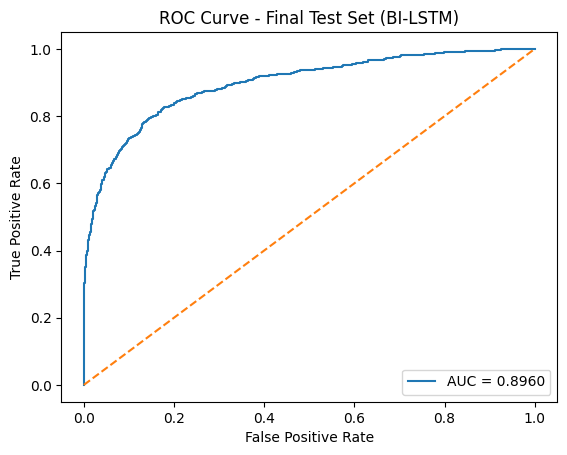

In [3]:
# =====================================================
# CELL 3 — FINAL TRAINING + EVALUATION
# =====================================================

import copy
import json

with open("hyperparameters_bilstm.json") as f:
    params=json.load(f)

print("Using hyperparameters:",params)

batch_size=params["batch_size"]
lr=params["lr"]
hidden_dim=params["hidden_dim"]
dropout=params["dropout"]

train_loader=DataLoader(TextDataset(X_train_pad,y_train),batch_size=batch_size,shuffle=True)
val_loader=DataLoader(TextDataset(X_val_pad,y_val),batch_size=batch_size)
test_loader=DataLoader(TextDataset(X_test_pad,y_test),batch_size=batch_size)


class BiLSTM(nn.Module):

    def __init__(self):

        super(BiLSTM,self).__init__()

        self.embedding=nn.Embedding.from_pretrained(
        embedding_matrix,
        freeze=True
        )

        self.lstm=nn.LSTM(
        embedding_dim,
        hidden_dim,
        batch_first=True,
        bidirectional=True
        )

        self.dropout=nn.Dropout(dropout)

        self.fc=nn.Linear(hidden_dim*2,1)

    def forward(self,x):

        x=self.embedding(x)

        _,(hidden,_)=self.lstm(x)

        hidden=torch.cat((hidden[0],hidden[1]),dim=1)

        hidden=self.dropout(hidden)

        out=self.fc(hidden)

        return out.squeeze()


model=BiLSTM().to(device)

criterion=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=lr)


epochs=20
patience=5
best_val_loss=float("inf")
counter=0
best_model_state=None

print("🚀 Training dengan Early Stopping (monitor = Val Loss)")

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()
    total_loss=0

    train_loop=tqdm(train_loader,desc=f"Epoch {epoch+1}/{epochs} - Training",leave=False)

    for X_batch,y_batch in train_loop:

        X_batch,y_batch=X_batch.to(device),y_batch.to(device)

        optimizer.zero_grad()

        outputs=model(X_batch)

        loss=criterion(outputs,y_batch)

        loss.backward()

        optimizer.step()

        total_loss+=loss.item()

        train_loop.set_postfix(loss=loss.item())

    # ================= VALIDATION =================
    model.eval()

    val_loss=0
    val_preds=[]
    val_true=[]

    val_loop=tqdm(val_loader,desc=f"Epoch {epoch+1}/{epochs} - Validation",leave=False)

    with torch.no_grad():

        for X_batch,y_batch in val_loop:

            X_batch=X_batch.to(device)
            y_batch=y_batch.to(device)

            outputs=model(X_batch)

            loss=criterion(outputs,y_batch)
            val_loss+=loss.item()

            probs=torch.sigmoid(outputs)

            preds=(probs>=0.5).cpu().numpy()

            val_preds.extend(preds)
            val_true.extend(y_batch.cpu().numpy())

    val_loss=val_loss/len(val_loader)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {total_loss/len(train_loader):.4f}")
    print(f"Validation Loss: {val_loss:.4f}")

    # ================= EARLY STOPPING =================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter=0
        best_model_state=copy.deepcopy(model.state_dict())

        print("✅ Model terbaik diperbarui")

    else:

        counter+=1

        print(f"⚠️ Tidak ada peningkatan ({counter}/{patience})")

        if counter>=patience:

            print("🛑 Early stopping triggered")
            break

print("✅ Training selesai")


# ================= EVALUATION =================

model.load_state_dict(best_model_state)
model.eval()

all_preds=[]
all_probs=[]

test_loop=tqdm(test_loader,desc="Testing",leave=False)

with torch.no_grad():

    for X_batch,_ in test_loop:

        X_batch=X_batch.to(device)

        outputs=model(X_batch)

        probs=torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())

        all_preds.extend((probs>=0.5).cpu().numpy())

y_pred=np.array(all_preds)
y_proba=np.array(all_probs)


print("\n=== FINAL TEST EVALUATION ===")

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1-score :",f1_score(y_test,y_pred))
print("AUC      :",roc_auc_score(y_test,y_proba))


print("\n=== CLASSIFICATION REPORT ===")

print(classification_report(y_test,y_pred,digits=4))


print("=== CONFUSION MATRIX ===")

print(confusion_matrix(y_test,y_pred))


fpr,tpr,_=roc_curve(y_test,y_proba)

roc_auc=auc(fpr,tpr)

plt.figure()

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Final Test Set (BI-LSTM)")
plt.legend(loc="lower right")

plt.show()

**f1**

Using hyperparameters: {'batch_size': 32, 'lr': 0.001, 'hidden_dim': 32, 'dropout': 0.5}
🚀 Training dengan Early Stopping (monitor = Val F1)



Epoch 1/20
Train Loss: 0.4236
Validation F1: 0.8529
✅ Model terbaik diperbarui



Epoch 2/20
Train Loss: 0.3186
Validation F1: 0.8585
✅ Model terbaik diperbarui



Epoch 3/20
Train Loss: 0.2860
Validation F1: 0.8650
✅ Model terbaik diperbarui



Epoch 4/20
Train Loss: 0.2631
Validation F1: 0.8622
⚠️ Tidak ada peningkatan (1/5)


...


Epoch 14/20
Train Loss: 0.1558
Validation F1: 0.8769
⚠️ Tidak ada peningkatan (2/5)



Epoch 15/20
Train Loss: 0.1532
Validation F1: 0.8726
⚠️ Tidak ada peningkatan (3/5)



Epoch 16/20
Train Loss: 0.1449
Validation F1: 0.8765
⚠️ Tidak ada peningkatan (4/5)



Epoch 17/20
Train Loss: 0.1360
Validation F1: 0.8723
⚠️ Tidak ada peningkatan (5/5)
🛑 Early stopping triggered
✅ Training selesai



=== FINAL TEST EVALUATION ===
Accuracy : 0.8285552086290093
Precision: 0.5331384015594542
Recall   : 0.8139880952380952
F1-score : 0.6442873969375736
AUC      : 0.8980913129895943

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9499    0.8320    0.8871      2851
           1     0.5331    0.8140    0.6443       672

    accuracy                         0.8286      3523
   macro avg     0.7415    0.8230    0.7657      3523
weighted avg     0.8704    0.8286    0.8408      3523

=== CONFUSION MATRIX ===
[[2372  479]
 [ 125  547]]


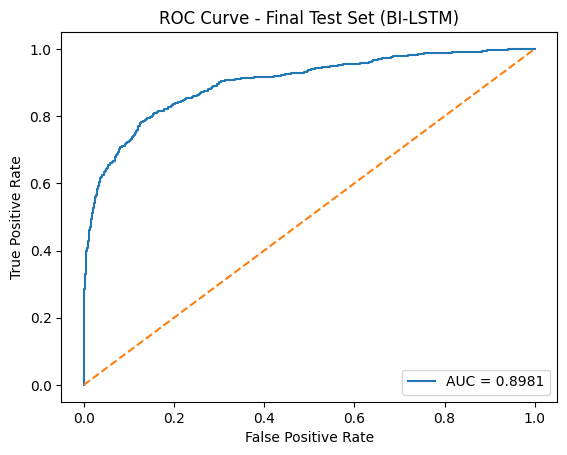

In [4]:
# =====================================================
# CELL 3 — FINAL TRAINING + EVALUATION (EARLY STOPPING F1)
# =====================================================

import copy
import json

with open("hyperparameters_bilstm.json") as f:
    params=json.load(f)

print("Using hyperparameters:",params)

batch_size=params["batch_size"]
lr=params["lr"]
hidden_dim=params["hidden_dim"]
dropout=params["dropout"]

train_loader=DataLoader(TextDataset(X_train_pad,y_train),batch_size=batch_size,shuffle=True)
val_loader=DataLoader(TextDataset(X_val_pad,y_val),batch_size=batch_size)
test_loader=DataLoader(TextDataset(X_test_pad,y_test),batch_size=batch_size)


class BiLSTM(nn.Module):

    def __init__(self):

        super(BiLSTM,self).__init__()

        self.embedding=nn.Embedding.from_pretrained(
        embedding_matrix,
        freeze=True
        )

        self.lstm=nn.LSTM(
        embedding_dim,
        hidden_dim,
        batch_first=True,
        bidirectional=True
        )

        self.dropout=nn.Dropout(dropout)

        self.fc=nn.Linear(hidden_dim*2,1)

    def forward(self,x):

        x=self.embedding(x)

        _,(hidden,_)=self.lstm(x)

        hidden=torch.cat((hidden[0],hidden[1]),dim=1)

        hidden=self.dropout(hidden)

        out=self.fc(hidden)

        return out.squeeze()


model=BiLSTM().to(device)

criterion=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=lr)

epochs=20
patience=5
best_f1=0
counter=0
best_model_state=None

print("🚀 Training dengan Early Stopping (monitor = Val F1)")

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()
    total_loss=0

    train_loop=tqdm(train_loader,desc=f"Epoch {epoch+1}/{epochs} - Training",leave=False)

    for X_batch,y_batch in train_loop:

        X_batch,y_batch=X_batch.to(device),y_batch.to(device)

        optimizer.zero_grad()

        outputs=model(X_batch)

        loss=criterion(outputs,y_batch)

        loss.backward()

        optimizer.step()

        total_loss+=loss.item()

        train_loop.set_postfix(loss=loss.item())

    # ================= VALIDATION =================
    model.eval()

    val_preds=[]
    val_true=[]

    val_loop=tqdm(val_loader,desc=f"Epoch {epoch+1}/{epochs} - Validation",leave=False)

    with torch.no_grad():

        for X_batch,y_batch in val_loop:

            X_batch=X_batch.to(device)

            outputs=model(X_batch)

            probs=torch.sigmoid(outputs)

            preds=(probs>=0.5).cpu().numpy()

            val_preds.extend(preds)
            val_true.extend(y_batch.numpy())

    val_f1=f1_score(val_true,val_preds)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {total_loss/len(train_loader):.4f}")
    print(f"Validation F1: {val_f1:.4f}")

    # ================= EARLY STOPPING =================
    if val_f1 > best_f1:

        best_f1 = val_f1
        counter = 0
        best_model_state = copy.deepcopy(model.state_dict())

        print("✅ Model terbaik diperbarui")

    else:

        counter += 1

        print(f"⚠️ Tidak ada peningkatan ({counter}/{patience})")

        if counter >= patience:

            print("🛑 Early stopping triggered")
            break

print("✅ Training selesai")


# ================= EVALUATION =================

model.load_state_dict(best_model_state)
model.eval()

all_preds=[]
all_probs=[]

test_loop=tqdm(test_loader,desc="Testing",leave=False)

with torch.no_grad():

    for X_batch,_ in test_loop:

        X_batch=X_batch.to(device)

        outputs=model(X_batch)

        probs=torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())

        all_preds.extend((probs>=0.5).cpu().numpy())

y_pred=np.array(all_preds)
y_proba=np.array(all_probs)


print("\n=== FINAL TEST EVALUATION ===")

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1-score :",f1_score(y_test,y_pred))
print("AUC      :",roc_auc_score(y_test,y_proba))


print("\n=== CLASSIFICATION REPORT ===")

print(classification_report(y_test,y_pred,digits=4))


print("=== CONFUSION MATRIX ===")

print(confusion_matrix(y_test,y_pred))


fpr,tpr,_=roc_curve(y_test,y_proba)

roc_auc=auc(fpr,tpr)

plt.figure()

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Final Test Set (BI-LSTM)")
plt.legend(loc="lower right")

plt.show()